# Lab 08: Vision Transformers and VLMs, Talking to Your Images

**ITAI 1378  |  Module 08 Companion Lab  |  2026**

**Author:** Patricia McManus     **Collaborator:** Claude (Anthropic)

**Course:** AI and Robotics Program, Digital and Information Technology Center of Excellence, Houston City College

---

In Module 08 you learned how Vision Transformers chop an image into patches and treat them like words, and how Vision Language Models (VLMs) connect a model's eyes to a language model so it can describe, answer, and reason about images. The frontier VLMs you studied (GPT-5.5, Claude Opus 4.7, the Gemini 3 family) cost money per image. Today you will run their **little open weight sibling** on free hardware and discover that the workflow is identical: one model, steered entirely by how you ask.

**By the end of this lab you will be able to:**

1. Visualize how a Vision Transformer "reads" an image as patches
2. Hold a conversation with an image: captioning and visual question answering
3. Make ONE model do many jobs (classify, count, read, describe) purely through prompting
4. Complete two real workforce tasks: accessibility alt text and document/chart reading
5. Audit a VLM's reliability and catch it hallucinating
6. Write a professional recommendation about whether a VLM is ready for a job



## How This Lab Works

* Cells marked **RUN AS IS** are complete. Run them and read the comments.
* Cells marked **YOUR CODE HERE** have a TODO for you to complete. Tips are in the comments.
* Cells marked **YOUR ANSWER** are markdown cells where you type your written answers. Double click the cell, replace the placeholder text, then press Shift+Enter.
* **YOUR TURN** sections are graded checkpoints. **Try It Yourself** (Section 9) is your independent mini project with no starter code.

### Your GPU Budget (read this!)

This lab is even lighter than Lab 07:

* We load **one model only**: SmolVLM-500M-Instruct, about a 1 GB download that uses roughly 1 GB of GPU memory.
* Each question you ask takes a few seconds. The whole lab needs a few dozen questions.
* The CPU fallback is genuinely usable this time. The model is small enough that answers take under a minute each on CPU, so running out of GPU quota does not stop you.
* Plan to finish in one sitting so the downloaded model stays cached.

**Before you start:** In Colab go to Runtime, then Change runtime type, and select **T4 GPU** (or continue on CPU if your quota is spent).

## Grading Rubric (100 points, bonus available)

**Implementation, 60 points (six items, 10 points each)**

| Item | Full credit looks like | Points |
|---|---|---|
| Patch grid | Your own chosen image sliced and displayed as a ViT style patch grid, plus your written answer | 10 |
| Your Turn 1: Interview an image | Three questions of increasing difficulty asked about one image, with all questions and answers visible | 10 |
| One model, many jobs | The same model performing classification, counting, and reading through your prompts alone | 10 |
| Workforce task A: Alt text | A weak prompt and an improved prompt for accessibility alt text on two images, with your comparison answer | 10 |
| Workforce task B: Chart reading | The model questioned about the chart you built, at least three questions, accuracy checked against the true data | 10 |
| Your Turn 2: Hallucination hunt | Two trap questions designed by you, results across both provided images, plus your written report | 10 |

**Analysis, 40 points**

| Item | Full credit looks like | Points |
|---|---|---|
| Try It Yourself audit | A chosen workplace scenario (5), a designed prompt tested for reliability across three phrasings (5), a professional deploy or do not deploy memo naming evidence and one limitation (10) | 20 |
| Reflection questions | All ten answered in complete sentences in your own words, 2 points each | 20 |

**Bonus, up to 20 points:** see Section 11.

**Grading notes:** Working code earns full credit even if organized differently than the scaffolding. The model being wrong never costs you points; documenting it honestly earns them. What is graded is your process and your judgment. There is no deduction for late submission.

**Academic integrity:** Written answers must be your own words. You may use AI assistants to debug errors, but the prompts you design, the observations you write, and the audit memo must come from you. Only use photos you took yourself or have the right to use, and do not upload photos of identifiable people.

**Submission:** This notebook is the only deliverable. Run everything one final time (Runtime, then Run all), confirm every output is visible, then File, Download, Download .ipynb **with all outputs visible**. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit to Canvas.

## Section 1: Setup

**RUN AS IS.** We install the Hugging Face libraries and detect your hardware. Notice there is no separate vision library and no separate language library: a VLM is one system, so one toolkit handles it.

In [ ]:
# RUN AS IS
!pip install -q transformers accelerate

import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.float16
    print("GPU ready:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    DTYPE = torch.float32
    print("CPU fallback active. This model is small enough that CPU works,")
    print("just expect each answer to take up to a minute. Be patient!")

GPU ready: Tesla T4


## Section 2: Seeing Like a Vision Transformer (Zero GPU Cost)

Before we talk to a VLM, let's see what its eyes actually receive. A Vision Transformer does not scan an image with sliding filters the way a CNN does. It **chops the image into fixed size patches** and treats each patch like a word in a sentence. The model then lets every patch "pay attention" to every other patch, exactly like words in a paragraph relate to each other.

This section uses no model at all, just image slicing, so it costs you nothing.

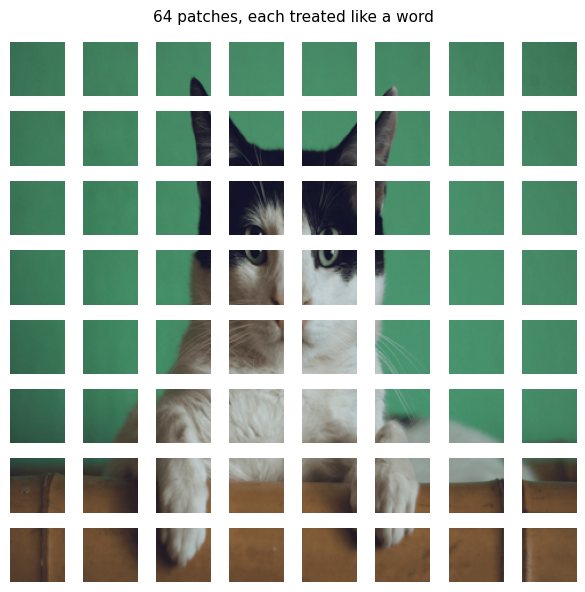

In [ ]:
# RUN AS IS
# Download a sample image and slice it into a ViT style patch grid.
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png"
urllib.request.urlretrieve(url, "sample_cat.png")
img = Image.open("sample_cat.png").convert("RGB").resize((384, 384))

def show_patches(image, patch_size=48):
    """Slice an image into square patches and display them as a spaced grid,
    the way a Vision Transformer sees its input."""
    w, h = image.size
    cols, rows = w // patch_size, h // patch_size
    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    for r in range(rows):
        for c in range(cols):
            patch = image.crop((c * patch_size, r * patch_size,
                                (c + 1) * patch_size, (r + 1) * patch_size))
            axes[r, c].imshow(patch)
            axes[r, c].axis("off")
    fig.suptitle(f"{rows * cols} patches, each treated like a word", fontsize=11)
    plt.tight_layout()
    plt.show()

show_patches(img)

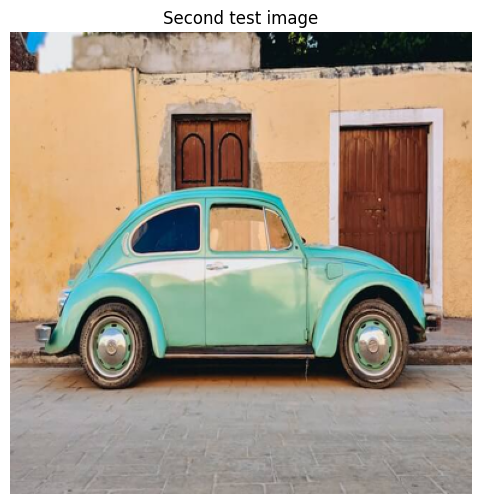

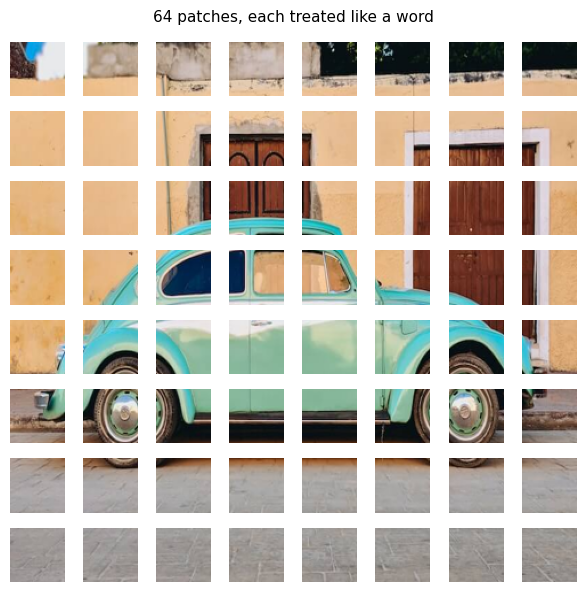

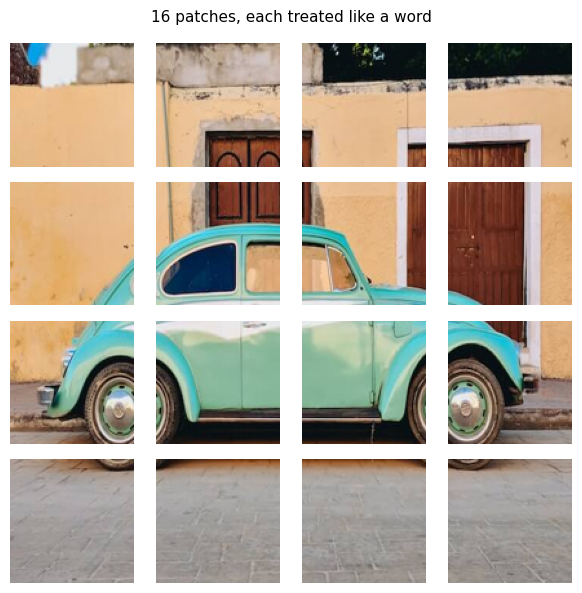

In [ ]:
# YOUR CODE HERE (Patch grid, graded, 10 pts)

# TODO: load a DIFFERENT image (upload your own with the Colab folder icon,
#       or reuse a different URL) and display its patch grid at TWO patch
#       sizes: 48 and 96.
# Tip: resize to (384, 384) first so the grid divides evenly.
# Tip: img2 = Image.open("/content/yourfile.jpg").convert("RGB").resize((384, 384))
#      then call show_patches(img2, patch_size=48) and again with 96.

# TODO: your code here
url2 = (
    "https://huggingface.co/datasets/huggingface/"
    "documentation-images/resolve/main/transformers/tasks/car.jpg"
)

urllib.request.urlretrieve(url2, "sample_car.jpg")

img2 = Image.open("sample_car.jpg").convert("RGB").resize((384, 384))

# Display the original second image
plt.figure(figsize=(6, 6))
plt.imshow(img2)
plt.title("Second test image")
plt.axis("off")
plt.show()

# Display two different patch sizes
show_patches(img2, patch_size=48)
show_patches(img2, patch_size=96)

### YOUR ANSWER (Patches)

*Double click and replace: With 48 pixel patches versus 96 pixel patches, which grid would give the model a more detailed "sentence" to read, and what is the tradeoff? Answer in two or three sentences using the words of an image analogy.*

## Section 3: Load the VLM and Have Your First Conversation

**RUN AS IS.** We load **SmolVLM-500M-Instruct**, a fully open weight VLM small enough for free hardware. Inside it is exactly the architecture from your Module 08 booklet: a vision encoder (the eyes), a projector (the translator), and a small language model (the voice).

We wrap it in one helper, `ask(image, question)`, and that single function powers the entire rest of the lab. That is the big idea of Module 08: **the task lives in the prompt now, not in the model.**

In [ ]:
# RUN AS IS
#============================ OUTDATED CODE ============================
#This ran into an error due to outdated modules. See the updated version.

# from transformers import AutoProcessor, AutoModelForVision2Seq

# MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

# processor = AutoProcessor.from_pretrained(MODEL_ID)
# model = AutoModelForVision2Seq.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)

# def ask(image, question, max_new_tokens=150):
#     """Ask the VLM one question about one image and return its answer."""
#     messages = [{"role": "user",
#                  "content": [{"type": "image"},
#                              {"type": "text", "text": question}]}]
#     prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
#     inputs = processor(text=prompt, images=[image], return_tensors="pt").to(DEVICE)
#     out = model.generate(**inputs, max_new_tokens=max_new_tokens)
#     answer = processor.batch_decode(out, skip_special_tokens=True)[0]
    # The decoded text contains the whole conversation; keep only the reply.
#     return answer.split("Assistant:")[-1].strip()

# print("VLM loaded. Say hello:")
# print(ask(img, "Describe this image in one sentence."))

#============================ FIXED CODE ============================
# RUN AS IS
from transformers import AutoProcessor, AutoModelForImageTextToText

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)

model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    dtype=DTYPE
).to(DEVICE)


def ask(image, question, max_new_tokens=150):
    """Ask the VLM a question and return only its answer."""

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": question}
            ]
        }
    ]

    prompt = processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    inputs = processor(
        text=prompt,
        images=[image],
        return_tensors="pt"
    ).to(DEVICE)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    # Remove the original prompt tokens
    new_tokens = generated_ids[:, inputs["input_ids"].shape[1]:]

    answer = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True
    )[0]

    return answer.strip()


print("VLM loaded. Say hello:")
print(ask(img, "Describe this image in one sentence."))

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

VLM loaded. Say hello:
A cat is resting its head on a wooden surface and looking at the camera.


### YOUR TURN 1: Interview an Image (Graded, 10 pts)

Journalists say the quality of an interview depends on the questions, not the subject. Same here. Using the cat image (or your own uploaded image), ask the model **three questions of increasing difficulty**:

1. An easy factual question (what is in the image)
2. A detail question (color, position, count, background)
3. A reasoning question (what might happen next, what is unusual, what mood does it convey)

Print each question with its answer so both are visible in your output.

In [ ]:
# YOUR CODE HERE (Your Turn 1)

# TODO: write your three questions and ask them.
# Tip: a loop keeps this readable:
# for q in [question_1, question_2, question_3]:
#     print("Q:", q)
#     print("A:", ask(img, q))
#     print()

question_1 = "TODO easy factual question"
question_2 = "TODO detail question"
question_3 = "TODO reasoning question"

# TODO: your loop here
for q in [question_1, question_2, question_3]:
    print("Q:", q)
    print("A:", ask(img, q))
    print()

Q: TODO easy factual question
A: What is the cat doing?

Q: TODO detail question
A: A cat with black and white fur is resting its head on a wooden surface and looking at the camera.

Q: TODO reasoning question
A: A cat is resting its head on a wooden surface and looking at the camera.



### YOUR ANSWER (Your Turn 1)

*Double click and replace: Which of your three questions got the weakest answer, and why do you think that level of question is harder for the model? Two or three sentences.*

## Section 4: One Model, Many Jobs (Graded, 10 pts)

Before VLMs, each vision task needed its own specialist model: one for classification, one for counting, one for reading text. A VLM replaces the whole shelf, because **the prompt selects the job**. Watch the demo, then make the model switch jobs yourself.

**Prompting tip that professionals rely on:** constrain the output format. "Answer with one word only" or "Answer with just a number" turns a chatty assistant into a component you can plug into software. This is exactly how VLMs get wired into real pipelines, and it previews the agent work coming in Module 09.

In [ ]:
# RUN AS IS
# Job 1, classification: the prompt turns the VLM into a classifier.
print("Classifier:", ask(img, "Is this a cat, a dog, or a bird? Answer with one word only."))

Classifier: Cat.


In [ ]:
# YOUR CODE HERE (Job switching)

# TODO: make the SAME model do two more jobs on the same image:
#   Job 2, counter: ask how many of something there are, demanding just a number.
#   Job 3, reader/describer: ask it to list every object it can see, one per line.
# Tip: the only thing you are allowed to change is the question string.
#      That is the whole point of this section.

# TODO: Job 2 here
count_question = "How many cats are visible in this image? Answer with just a number."
print("Counter:", ask(img, count_question))

# TODO: Job 3 here
list_question = (
    "List every clearly visible object in this image. "
    "Put one object on each line and do not explain."
)

print("Object list:")
print(ask(img, list_question))


Counter: 1.
Object list:
Cat.


### YOUR ANSWER (One model, many jobs)

*Double click and replace: In Module 06 you used a dedicated detector (YOLO) for finding objects. Name one advantage the specialist detector still has over the VLM you just prompted, and one advantage the VLM has over the specialist. Two or three sentences.*

## Section 5: Workforce Task A, Accessibility Alt Text (Graded, 10 pts)

Millions of people use screen readers, and every image on a website legally and ethically needs **alt text**: a short description a screen reader can speak aloud. Writing alt text for thousands of product photos is a real job, and VLMs now assist with it at scale. But quality depends entirely on the prompt.

Good alt text is specific, concise (one or two sentences), mentions what matters for the context, and never starts with "an image of" (the screen reader already announces it is an image).

Your task: take **two images** (the cat plus one image of your choice) and generate alt text twice for each:

1. First with a **weak prompt**: just "Describe this image."
2. Then with a **professional prompt you write** that encodes the rules above.

In [ ]:
# YOUR CODE HERE (Workforce task A)

# TODO: write your professional alt text prompt. Encode the rules:
#       concise, specific, useful for a shopper or reader, never "an image of".
# Tip: you can put instructions AND constraints in one question, for example:
#      "Write alt text for this image for a screen reader user. One sentence,
#       specific, do not begin with the words an image of."

weak_prompt = "Describe this image."
pro_prompt = "TODO your professional alt text prompt"

# TODO: run both prompts on BOTH images and print all four results, clearly
#       labeled so the improvement is easy to see.
test_images = [
    ("Cat image", img),
    ("Car image", img2)
]

for image_name, test_image in test_images:
    print("=" * 60)
    print(image_name)

    print("\nWEAK PROMPT OUTPUT:")
    print(ask(test_image, weak_prompt))

    print("\nPROFESSIONAL PROMPT OUTPUT:")
    print(ask(test_image, pro_prompt))
    print()

Cat image

WEAK PROMPT OUTPUT:
The image depicts a domestic cat resting on a wooden surface, likely a table or shelf. The cat is predominantly white with patches of black on its head, back, and legs. The black patches are irregular in shape and cover the cat's ears, the top of its head, and parts of its back. The cat's eyes are green, and its fur appears soft and well-groomed.

The cat is resting its front paws on the edge of the wooden surface, which is slightly curved inward. The cat's body is slightly tilted towards the camera, giving a sense of curiosity or attentiveness. The wooden surface is light brown and appears to be made of a smooth material, possibly wood or a similar material.

The

PROFESSIONAL PROMPT OUTPUT:
A cat with black and white fur is resting its head on a wooden surface and looking at the camera.

Car image

WEAK PROMPT OUTPUT:
The image depicts a vintage car parked on a paved road in front of a building. The car is a small, light-colored vehicle, likely a Volksw

### YOUR ANSWER (Alt text)

*Double click and replace: Compare the weak and professional outputs. What specifically improved, and what would you still fix by hand before publishing? Two or three sentences.*

## Section 6: Workforce Task B, Reading Documents and Charts (Graded, 10 pts)

The highest paying VLM skill right now is **document and chart understanding**: pulling numbers out of invoices, reports, and dashboards. Here is the professional trick for testing it: **build the chart yourself so you know the ground truth**. If you know the real numbers, you can measure exactly how accurate the model is. Never trust an extraction you cannot check.

**RUN AS IS** builds a sales chart with known values. Then you interrogate it.

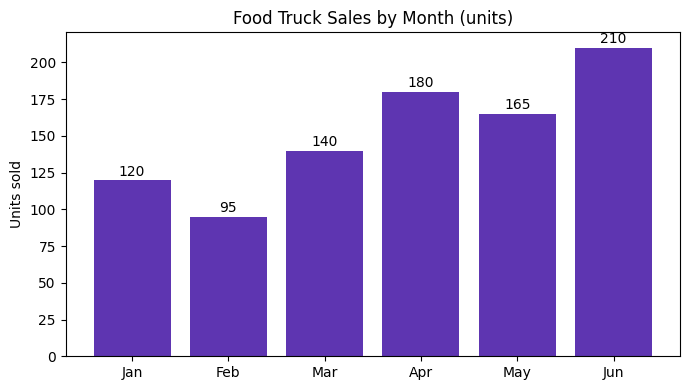

Chart built. Ground truth: {'Jan': 120, 'Feb': 95, 'Mar': 140, 'Apr': 180, 'May': 165, 'Jun': 210}


In [ ]:
# RUN AS IS
# Build a bar chart with KNOWN values, save it, and load it as an image.
import matplotlib.pyplot as plt
from PIL import Image

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = [120, 95, 140, 180, 165, 210]   # ground truth, we KNOW these numbers

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(months, sales, color="#5E35B1")
ax.set_title("Food Truck Sales by Month (units)")
ax.set_ylabel("Units sold")
for i, v in enumerate(sales):
    ax.text(i, v + 3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("sales_chart.png", dpi=110)
plt.show()

chart = Image.open("sales_chart.png").convert("RGB")
print("Chart built. Ground truth:", dict(zip(months, sales)))

In [ ]:
# YOUR CODE HERE (Workforce task B)

# TODO: ask the model AT LEAST three questions about the chart and print the
#       answers next to the true values so accuracy is visible. Ideas:
#   1. Which month had the highest sales?
#   2. How many units were sold in March? (Answer with just the number.)
#   3. Did sales go up or down between April and May?
# Tip: ask(chart, your_question)
# Tip: at least one question should require comparing two bars, which is
#      harder than reading one printed number.

# TODO: your questions here
chart_questions = [
    (
        "Which month had the highest sales? Answer with the month only.",
        "Jun"
    ),
    (
        "How many units were sold in March? Answer with just the number.",
        "140"
    ),
    (
        "Did sales go up or down from April to May? Answer with one word.",
        "down"
    ),
    (
        "How many more units were sold in June than January? "
        "Answer with just the number.",
        "90"
    )
]

for question, truth in chart_questions:
    model_answer = ask(chart, question)

    print("Q:", question)
    print("MODEL:", model_answer)
    print("TRUE:", truth)
    print()

Q: Which month had the highest sales? Answer with the month only.
MODEL: Jun
TRUE: Jun

Q: How many units were sold in March? Answer with just the number.
MODEL: 140.
TRUE: 140

Q: Did sales go up or down from April to May? Answer with one word.
MODEL: Up.
TRUE: down

Q: How many more units were sold in June than January? Answer with just the number.
MODEL: 65.
TRUE: 90



### YOUR ANSWER (Chart reading)

*Double click and replace: Score the model: how many of your questions did it answer correctly against the ground truth? Would you trust it unsupervised with a company's financial dashboard? Two or three sentences.*

## Section 7: YOUR TURN 2, The Hallucination Hunt (Graded, 10 pts)

Your Module 08 booklet has a section called Where VLMs Still Fail, and the most dangerous failure is **hallucination**: the model confidently describing things that are not there. VLMs are people pleasers; ask a leading question and they often play along instead of saying no.

Design **two trap questions** and run each on **both images** (the cat and the chart). A trap question presupposes something false, for example:

* "What color is the dog's collar?" (asked about an image with no dog)
* "What does the sign in the background say?" (no sign exists)
* "Why did sales drop in June?" (they rose)

A model passes the trap by correcting you. It fails by inventing an answer.

In [ ]:
# YOUR CODE HERE (Your Turn 2)

# TODO: write two trap questions of your own (do not copy the examples) and
#       run each on BOTH images, printing all four exchanges clearly.
# Tip: the best traps sound casual and confident, exactly like a distracted
#      coworker would ask.

trap_1 = "TODO your first trap question"
trap_2 = "TODO your second trap question"

# TODO: run both traps on img and on chart, print all four Q and A pairs
trap_images = [
    ("Cat image", img),
    ("Sales chart", chart)
]

for image_name, test_image in trap_images:
    print("=" * 60)
    print(image_name)

    for trap_number, question in enumerate([trap_1, trap_2], start=1):
        print(f"\nTRAP {trap_number}")
        print("Q:", question)
        print("A:", ask(test_image, question))

    print()

Cat image

TRAP 1
Q: TODO your first trap question
A: A green background and a cat on a wooden surface.

TRAP 2
Q: TODO your second trap question
A: Green background.

Sales chart

TRAP 1
Q: TODO your first trap question
A: The y-axis shows Units sold using a linear scale with a minimum of 0 and a maximum of 210. There is a categorical scale from Jan to Jun along the x-axis, marked Food Truck Sales by Month (units). The graph shows that the highest sales were in Jun, at 210 units. The lowest sales were in Feb, at 95 units.

TRAP 2
Q: TODO your second trap question
A: The y-axis shows Units sold using a linear scale with a minimum of 0 and a maximum of 210. There is a categorical scale from Jan to Jun along the x-axis, marked Food Truck Sales by Month (units). Jun has the highest number of units sold.



### YOUR ANSWER (Hallucination report)

*Double click and replace: For each trap, did the model correct you or play along? Why is this failure mode more dangerous in a workplace than simply getting a count wrong? Three or four sentences.*

## Section 8: Preview, The Agent's Eyes (Bridge to Module 09)

**RUN AS IS.** In Module 09 you will build AI agents that perceive, reason, and act. Their perception step is exactly what you have been doing all lab: a VLM answering questions about what it sees. Here is a thirty second preview: we ask the model not just to describe, but to **recommend an action**, which is the seed of the agent loop.

In [ ]:
# RUN AS IS
# The same ask() function, but the prompt now requests a decision.
agent_question = (
    "You are a monitoring assistant for a pet daycare. Based on this camera "
    "image, report the situation in one sentence and recommend one action. "
    "Format: SITUATION: ... ACTION: ..."
)
print(ask(img, agent_question))

Monitor the cat's eye color.


Notice what changed: nothing in the model, everything in the prompt. Perception plus a decision format is the doorway to agents. Hold that thought for two weeks.

## Section 9: Try It Yourself, The Deployment Audit (Graded, 20 pts)

This section is fully yours. No scaffolding, no starter code. Your only tools: `ask()`, `show_patches()`, matplotlib, and your judgment.

**The scenario:** You are a junior CV technician. Your manager is considering using a small VLM for one workplace task and asks you to **audit it before anyone trusts it**. You choose the scenario:

* Retail: describing product photos for a store website
* Safety: reporting what is visible on a workplace camera image
* Accessibility: alt text for a community organization's photo library
* Education: describing diagrams or charts for students
* Your own idea (name it clearly)

**Your deliverable, in cells you write yourself:**

1. **The scenario and test set (5 pts):** name your scenario and assemble two or three test images that fit it (upload your own, reuse the chart trick from Section 6 to build controlled test images, or reuse the provided images if they genuinely fit).
2. **The reliability test (5 pts):** design ONE prompt for the task, then test it for consistency by asking the same thing **three different ways** (rephrase it twice) on the same image. A dependable tool gives consistent answers; a fragile one changes its story.
3. **The audit memo (10 pts):** in the answer cell below, write a five to eight sentence memo to your manager: what you tested, what the model got right, what it got wrong or inconsistent, one hallucination risk specific to your scenario, and your verdict: deploy with human review, deploy unsupervised, or do not deploy. Take a position and defend it with your evidence.

**GPU saver:** ten to fifteen questions total is plenty. A sharp audit beats a big one.

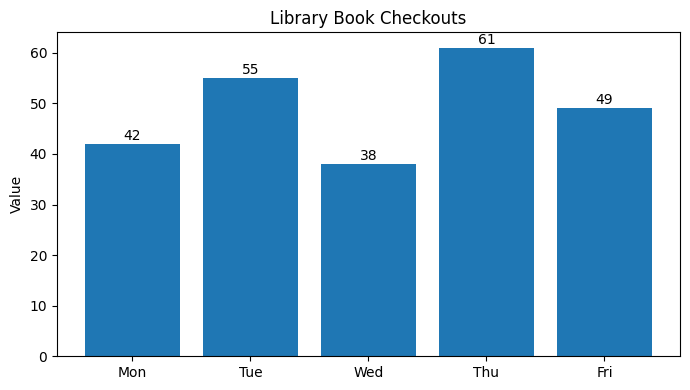

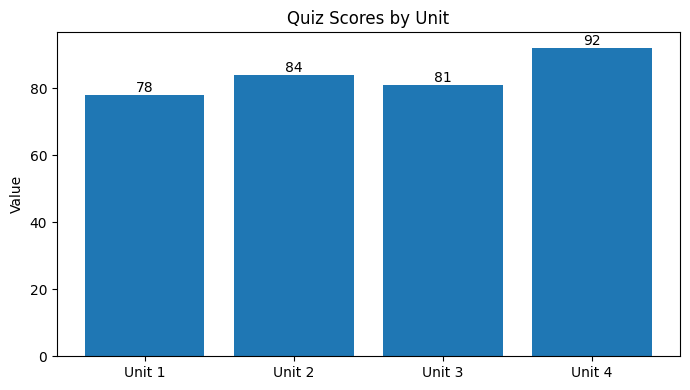

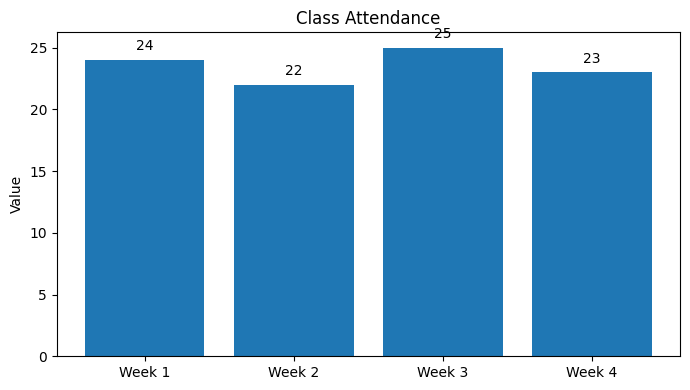


TEST CHART: Library Book Checkouts
GROUND TRUTH: {'Mon': 42, 'Tue': 55, 'Wed': 38, 'Thu': 61, 'Fri': 49}

PROMPT VERSION 1:
Describe this chart for a student. State the highest category and value, the lowest category and value, and the overall pattern. Use only information visible in the chart.
MODEL ANSWER:
The highest value is 90, which is for the category Thu. The lowest value is 38, which is for the category Wed. The overall pattern is that the value increases as the category increases.

PROMPT VERSION 2:
Help a student understand this graph. Identify the maximum and minimum categories with their exact values, then summarize the general pattern. Do not guess.
MODEL ANSWER:
Mon - 42
Tue - 55
Wed - 38
Thu - 91
Fri - 61

PROMPT VERSION 3:
Read this chart carefully. Report the category with the largest value, the category with the smallest value, and a one-sentence summary of the pattern. Mention exact values only when visible.
MODEL ANSWER:
Thu has the largest value at 90. Wed has th

In [ ]:
# YOUR CODE HERE (Try It Yourself)
# Build your audit below. Add as many cells as you need.
# Your toolbox:
#   ask(image, question)
#   show_patches(image, patch_size=...)
#   matplotlib and PIL for building controlled test images
# Reminder: print every question next to its answer so your memo's evidence
# is visible in the notebook output.

# Scenario: Education — describing simple charts for students.

audit_specs = [
    {
        "title": "Library Book Checkouts",
        "labels": ["Mon", "Tue", "Wed", "Thu", "Fri"],
        "values": [42, 55, 38, 61, 49]
    },
    {
        "title": "Quiz Scores by Unit",
        "labels": ["Unit 1", "Unit 2", "Unit 3", "Unit 4"],
        "values": [78, 84, 81, 92]
    },
    {
        "title": "Class Attendance",
        "labels": ["Week 1", "Week 2", "Week 3", "Week 4"],
        "values": [24, 22, 25, 23]
    }
]

audit_images = []

for index, spec in enumerate(audit_specs, start=1):
    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(spec["labels"], spec["values"])
    ax.set_title(spec["title"])
    ax.set_ylabel("Value")

    for i, value in enumerate(spec["values"]):
        ax.text(i, value + 0.8, str(value), ha="center")

    plt.tight_layout()

    filename = f"audit_chart_{index}.png"
    plt.savefig(filename, dpi=120)
    plt.show()
    plt.close(fig)

    audit_image = Image.open(filename).convert("RGB")
    audit_images.append(audit_image)

# The same task is asked three different ways to test consistency.
audit_prompts = [
    (
        "Describe this chart for a student. State the highest category and "
        "value, the lowest category and value, and the overall pattern. "
        "Use only information visible in the chart."
    ),
    (
        "Help a student understand this graph. Identify the maximum and "
        "minimum categories with their exact values, then summarize the "
        "general pattern. Do not guess."
    ),
    (
        "Read this chart carefully. Report the category with the largest "
        "value, the category with the smallest value, and a one-sentence "
        "summary of the pattern. Mention exact values only when visible."
    )
]

for spec, audit_image in zip(audit_specs, audit_images):
    print("\n" + "=" * 70)
    print("TEST CHART:", spec["title"])
    print("GROUND TRUTH:", dict(zip(spec["labels"], spec["values"])))

    for prompt_number, prompt in enumerate(audit_prompts, start=1):
        print(f"\nPROMPT VERSION {prompt_number}:")
        print(prompt)
        print("MODEL ANSWER:")
        print(ask(audit_image, prompt, max_new_tokens=180))

### YOUR ANSWER (Audit memo)

I tested the VLM for an educational use case in which it described three simple charts for students using three different prompt variations. The model sometimes correctly identified the highest or lowest category and generally understood that the images were charts. However, its answers were inconsistent when the same task was reworded, and the VLM frequently misread exact values and rankings. For example, it reported incorrect values for the library-checkout chart, confused the quiz-score rankings, and misread several class-attendance values. A scenario-specific hallucination risk is that the model could confidently invent a chart value and cause a student to learn or submit incorrect information. Based on these results, I do not recommend deploying the model unsupervised for educational chart interpretation. It could be used only as a limited support tool with human review, ground-truth checks, and clear warnings that its numerical answers may be inaccurate.

## Section 10: Reflection Questions (Graded, 20 pts, 2 each)

Answer each question in complete sentences directly in its YOUR ANSWER cell. Short bullet answers will not earn full credit. I want your reasoning in your own words.

**Q1. Patches as words.** Explain to a friend with no AI background how a Vision Transformer reads an image, using the patch grid you made in Section 2. Use your own analogy, not one from this notebook.

### YOUR ANSWER

Vision Transformers reads an image by dividing it into many small square patches, like cutting a large photograph into a set of numbered puzzle pieces. Each patch is then converted into numerical information describing its colors, shapes, and patterns. The models then studiy how these patches relate to one another, including where each patch belongs in the original image. By combining the information from all the patches, it can recognize the complete subject and scene.

**Q2. The three part architecture.** A VLM has eyes (vision encoder), a translator (projector), and a voice (language model). When your model hallucinated in Section 7, which part do you suspect was most responsible, and why?

### YOUR ANSWER

I suspect the language model, or the “voice,” was most responsible for the hallucination. The vision encoder may not have detected evidence that the requested object or detail was present, but the language model still attempted to produce a fluent and helpful response. Instead of questioning the false assumption in the prompt, it generated an answer that sounded believable. This shows how the language-generation part of a VLM can sometimes respond confidently even when the visual evidence is missing.

**Q3. The prompt is the task.** In Section 4 one model did several jobs. What does this mean for how CV teams will be organized in the workplace: fewer specialist models to maintain, or new problems to manage? Name one of each.

### YOUR ANSWER

One VLM was able to perform several jobs, including describing an image, counting objects, and listing visible items, simply by changing the prompt. This could mean that CV teams need fewer separate specialist models to build, train, and maintain. For example, one general VLM could replace separate systems for image captioning and object counting. However, teams would face new problems involving prompt design, output consistency, hallucinations, and testing each task separately before deployment.

**Q4. Constrained outputs.** Why does "answer with just a number" matter so much when a VLM is wired into software instead of chatting with a person? Give a concrete example of what breaks without it.

### YOUR ANSWER

“Answer with just a number” matters because software often expects an exact format rather than a conversational response. For example, an inventory system may need the model to return 3 so the result can be stored in a numerical database field and used in calculations. If the model instead returns “There appear to be about three items,” the software may fail to convert the answer into an integer. Constrained outputs make the model’s responses easier and safer for other programs to process automatically.

**Q5. Small versus frontier.** You used a 500 million parameter open model today; Module 08 covered frontier models thousands of times larger. Name two workplace situations where the small local model is the RIGHT choice even though it is weaker.

### YOUR ANSWER

Small local models are the right choice when a workplace handles private images that should not be uploaded to an outside cloud service, such as patient documents, internal security footage, or confidential manufacturing images. It is also useful in locations with unreliable internet access, such as a warehouse, remote field site, or factory floor. Even though the small model is weaker, it can provide faster responses, lower operating costs, offline access, and greater control over sensitive data. These advantages may be more important than achieving the highest possible accuracy.

**Q6. Alt text ethics.** Who is harmed when auto generated alt text is wrong, and why is "a human reviews every caption" easier to promise than to deliver at the scale of a real website?

### YOUR ANSWER

Incorrect automatically generated alt text can harm blind and visually impaired users because they depend on screen readers to understand visual information. This is because false descriptions may cause them to misunderstand a product, event, person, chart, or safety-related situation. Promising that a human will review every caption is easier than actually doing it because real websites may contain thousands or millions of images that are added and updated continuously. Human review also requires trained staff, time, funding, and a clear process for correcting mistakes.

**Q7. Ground truth.** In Section 6 you built the chart yourself so you knew the true numbers. Why is this a professional habit, and what goes wrong when teams evaluate AI tools on data where nobody knows the right answers?

### YOUR ANSWER

Creating the chart myself was a professional habit because it gave me a known ground truth that I could use to judge the model’s answers objectively. I knew the exact values, highest month, lowest month, and differences between categories before testing the VLM. When teams test AI tools on data where nobody knows the correct answers, a confident response may appear accurate even when it is wrong. Without ground truth, teams cannot calculate reliability, identify repeated failure patterns, or make a responsible deployment decision.

**Q8. Hallucination versus error.** Using your Section 7 results, explain the difference between a model being wrong and a model hallucinating. Why is the second one harder to catch in a busy workplace?

### YOUR ANSWER

A model makes an ordinary error when it attempts to read something that is actually present but gives the wrong answer. For example, the model made an error when it said sales increased from April to May even though the chart showed a decrease. A hallucination is different because the model invents an object, label, number, or detail that does not exist in the image. In my Section 7 test, the model invented and found a way to challenge the false assumptions. This is important because hallucinations are more difficult to catch in a busy workplace because they are often expressed in clear and confident language, causing employees to trust them without checking the original image.

**Q9. The audit mindset.** Your Try It Yourself verdict required taking a position. What evidence would have changed your verdict to the opposite one? Being able to answer this is what separates an audit from an opinion.

### YOUR ANSWER

My audit verdict was do not deploy the model unsupervised for describing educational charts. Although it occasionally identified the correct highest or lowest category, its answers changed when the same task was rephrased. It reported Thursday’s library checkouts as 90 or 91 instead of 61, confused the quiz-score rankings, and repeatedly misread the class-attendance values. Evidence that would have changed my verdict would include consistently identifying the correct maximum, minimum, and exact values across all three charts and all three prompt variations. I would also need additional testing to show that the model does not invent values and clearly admits when information is uncertain. Defining the evidence that could reverse my decision makes the conclusion an audit based on measurable performance rather than a personal opinion.

**Q10. Changed mind.** Before this lab, what did you believe about how AI understands images that turned out to be wrong or incomplete? Be specific about which section changed your mind.

### YOUR ANSWER

Before this lab, I thought an image AI examined a picture as one complete object in a way similar to human vision. After doing the lab, Section 2 changed my understanding because the patch-grid activity showed that a Vision Transformer first divides the image into small patches and processes them as numerical tokens. Sections 6 and 7 also showed me that recognizing visual patterns does not mean the model fully understands whether every statement is true. The model can produce a fluent answer while misreading a value or inventing a detail that is not visible.

## Section 11: Optional Bonus Challenges (up to +20)

Each completed challenge earns 5 bonus points. Pick any, all, or none. All four are light on compute.

**Bonus A, The tiny sibling (+5):** Load `HuggingFaceTB/SmolVLM-256M-Instruct` (half the size, a fast extra download) and rerun your three Your Turn 1 questions on it. In one or two sentences: what did shrinking the model cost?

When shrinking the model from 500M to 256M, this reduced its memory and computational requirements, but the smaller model’s responses were less detailed, especially for Question 3. It still was able to describe some objects seen in the provided pictures, showing the tradeoff between efficiency and response quality.

---

**Bonus B, The receipt reader (+5):** Using PIL, draw your own fake receipt image (store name, three items with prices, a total) with `ImageDraw.text`, then ask the model to extract the total and one item price. You know the ground truth because you drew it.

The model returned 15.50 for the receipt total and 2.25 for the price of Pens. The known ground-truth answers were 15.50 and 2.25, so this implies that both answers were correct.

---

**Bonus C, The patch size probe (+5):** Take one image with small important detail (text or a small object). Show its patch grid at 96 pixels, then ask the model a question about that small detail. Connect what you see in the grid to how the model answered, in one or two sentences.

In the 96-pixel patch grid, the small receipt number occupied only a small portion of the image and was located inside one of the upper patches as seen in the results. Despite its small size, the model correctly read the receipt number as A17.

---

**Bonus D, Your own photo set (+5):** Complete your Try It Yourself audit entirely with photos you took yourself. If you already did, say so here and point to the cells.

Reloading the 500M model because earlier setup is not in memory...


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.02GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

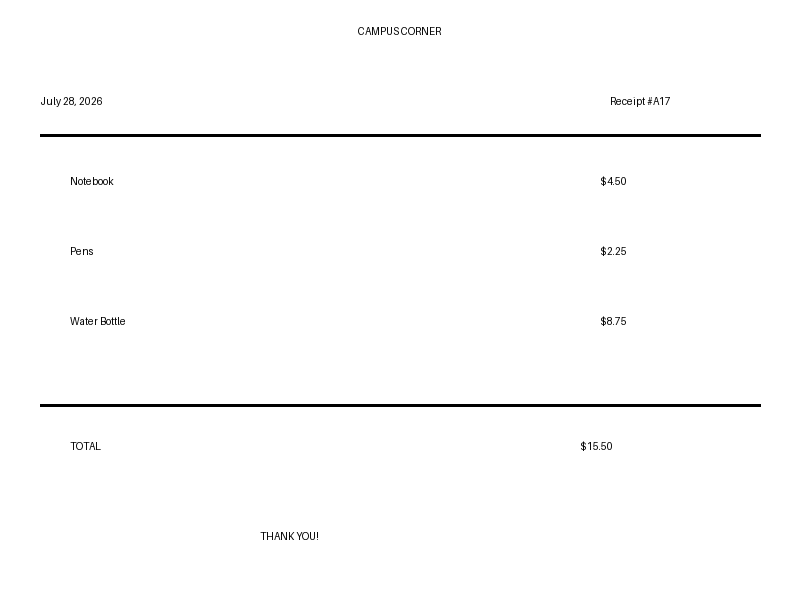


BONUS B RESULTS
Model total: $15.50.
True total: $15.50
Model Pens price: $2.25.
True Pens price: $2.25


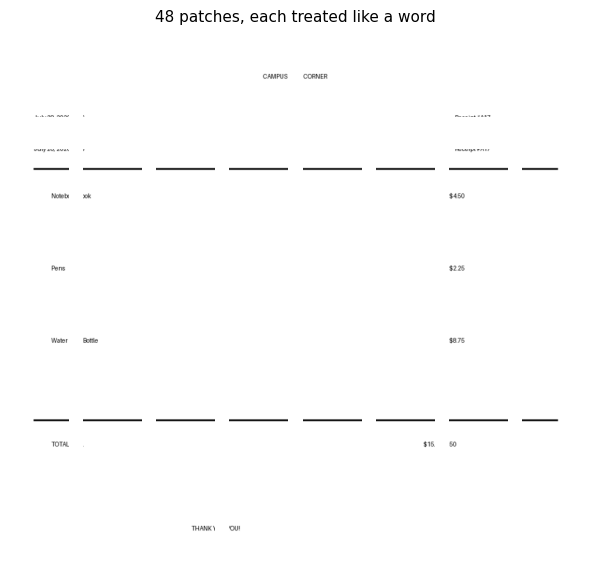


BONUS C RESULTS
Model answer: A17.
Ground truth: A17


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/7.35k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  513MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]


BONUS A COMPARISON

QUESTION 1: What animal is the main subject of this image?
500M ANSWER: There is a cat in the center of the image.
256M ANSWER: The main subject of this image is a cat.

QUESTION 2: What colors are visible on the animal, and where is it positioned?
500M ANSWER: The animal is white and black in color, and it is positioned on a wooden surface.
256M ANSWER: The animal is white and black in color.

QUESTION 3: What mood does the scene convey, and which visible details support your interpretation?
500M ANSWER: The scene conveys a calm and relaxed mood. The cat is lying down with its paws on a wooden surface, which suggests it is comfortable and at ease. The green background and the cat's calm demeanor support this interpretation.
256M ANSWER: The image does not convey a specific mood or mood-related details.


In [2]:
# YOUR CODE HERE (Optional bonus work)
# Label each attempt clearly with a comment: # BONUS A, # BONUS B, etc.
# Memory tip for Bonus A: load the 256M model AFTER you finish everything
# else, and if memory complains, run:
#   del model; import gc; gc.collect(); torch.cuda.empty_cache()
# before loading the smaller one.

import gc
import urllib.request
import torch
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
from transformers import AutoProcessor

try:
    from transformers import AutoModelForImageTextToText as VLMModel
except ImportError:
    from transformers import AutoModelForVision2Seq as VLMModel


# ============================================================
# RESTART-SAFE SETUP
# ============================================================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

BASE_MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"


def define_base_ask():
    """Load the 500M model when earlier cells were not run."""

    global processor, model, ask

    processor = AutoProcessor.from_pretrained(BASE_MODEL_ID)

    model = VLMModel.from_pretrained(
        BASE_MODEL_ID,
        torch_dtype=DTYPE
    ).to(DEVICE)

    model.eval()

    @torch.inference_mode()
    def ask(image, question, max_new_tokens=150):
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": question}
                ]
            }
        ]

        prompt = processor.apply_chat_template(
            messages,
            add_generation_prompt=True
        )

        inputs = processor(
            text=prompt,
            images=[image],
            return_tensors="pt"
        ).to(DEVICE)

        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

        # Remove the original prompt tokens.
        new_tokens = generated_ids[
            :,
            inputs["input_ids"].shape[1]:
        ]

        answer = processor.batch_decode(
            new_tokens,
            skip_special_tokens=True
        )[0]

        return answer.strip()


if "small_model" in globals():
    del small_model

if "small_processor" in globals():
    del small_processor

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Reload the base model if the runtime restarted.
required_base_names = [
    "processor",
    "model",
    "ask"
]

if not all(name in globals() for name in required_base_names):
    print(
        "Reloading the 500M model because earlier setup "
        "is not in memory..."
    )

    define_base_ask()


# Restore the sample cat if the runtime restarted.
if "img" not in globals():
    cat_url = (
        "https://huggingface.co/datasets/huggingface/"
        "documentation-images/resolve/main/diffusers/cat.png"
    )

    urllib.request.urlretrieve(
        cat_url,
        "sample_cat.png"
    )

    img = (
        Image.open("sample_cat.png")
        .convert("RGB")
        .resize((384, 384))
    )


# Restore show_patches if the runtime restarted.
if "show_patches" not in globals():

    def show_patches(image, patch_size=48):
        width, height = image.size

        columns = width // patch_size
        rows = height // patch_size

        fig, axes = plt.subplots(
            rows,
            columns,
            figsize=(6, 6)
        )

        for row in range(rows):
            for column in range(columns):
                patch = image.crop(
                    (
                        column * patch_size,
                        row * patch_size,
                        (column + 1) * patch_size,
                        (row + 1) * patch_size
                    )
                )

                axes[row, column].imshow(patch)
                axes[row, column].axis("off")

        fig.suptitle(
            f"{rows * columns} patches, "
            "each treated like a word",
            fontsize=11
        )

        plt.tight_layout()
        plt.show()




def load_font(size):
    """Load a readable Colab font with a fallback."""

    font_paths = [
        "/usr/share/fonts/truetype/dejavu/"
        "DejaVuSansMono.ttf",

        "/usr/share/fonts/truetype/dejavu/"
        "DejaVuSans.ttf"
    ]

    for font_path in font_paths:
        try:
            return ImageFont.truetype(
                font_path,
                size=size
            )

        except OSError:
            continue

    return ImageFont.load_default()


title_font = load_font(40)
body_font = load_font(30)
small_font = load_font(18)
total_font = load_font(34)


# Create the fake receipt.
receipt_img = Image.new(
    "RGB",
    (800, 600),
    "white"
)

draw = ImageDraw.Draw(receipt_img)


# Draw the store name.
store_name = "CAMPUS CORNER"

store_box = draw.textbbox(
    (0, 0),
    store_name,
    font=title_font
)

store_width = store_box[2] - store_box[0]

draw.text(
    (
        (800 - store_width) // 2,
        25
    ),
    store_name,
    fill="black",
    font=title_font
)


# Draw the date and receipt number.
draw.text(
    (40, 95),
    "July 28, 2026",
    fill="black",
    font=small_font
)

draw.text(
    (610, 95),
    "Receipt #A17",
    fill="black",
    font=small_font
)

draw.line(
    (40, 135, 760, 135),
    fill="black",
    width=3
)


# Receipt items and prices.
receipt_items = [
    ("Notebook", 4.50),
    ("Pens", 2.25),
    ("Water Bottle", 8.75)
]

y = 175

for item_name, item_price in receipt_items:
    draw.text(
        (70, y),
        item_name,
        fill="black",
        font=body_font
    )

    draw.text(
        (600, y),
        f"${item_price:.2f}",
        fill="black",
        font=body_font
    )

    y += 70


# Draw the total.
draw.line(
    (40, 405, 760, 405),
    fill="black",
    width=3
)

draw.text(
    (70, 440),
    "TOTAL",
    fill="black",
    font=total_font
)

draw.text(
    (580, 440),
    "$15.50",
    fill="black",
    font=total_font
)

draw.text(
    (260, 530),
    "THANK YOU!",
    fill="black",
    font=body_font
)


# Display the receipt.
display(receipt_img)


# Ask the VLM to read the receipt.
total_answer = ask(
    receipt_img,
    "What is the total amount on this receipt? "
    "Answer with just the dollar amount."
)

pens_answer = ask(
    receipt_img,
    "What is the price of Pens on this receipt? "
    "Answer with just the dollar amount."
)


print("\nBONUS B RESULTS")

print(
    "Model total:",
    total_answer
)

print(
    "True total: $15.50"
)

print(
    "Model Pens price:",
    pens_answer
)

print(
    "True Pens price: $2.25"
)




# Resize the receipt to dimensions divisible by 96.
receipt_probe = receipt_img.resize(
    (768, 576)
)

# Display the 96-pixel patch grid.
show_patches(
    receipt_probe,
    patch_size=96
)


# Ask about the small receipt number.
small_detail_answer = ask(
    receipt_probe,
    "What is the receipt number printed near the "
    "upper-right corner? "
    "Answer with only the receipt number."
)


print("\nBONUS C RESULTS")

print(
    "Model answer:",
    small_detail_answer
)

print(
    "Ground truth: A17"
)



# BONUS A

bonus_a_questions = [
    "What animal is the main subject of this image?",

    (
        "What colors are visible on the animal, "
        "and where is it positioned?"
    ),

    (
        "What mood does the scene convey, and which "
        "visible details support your interpretation?"
    )
]


answers_500m = [
    ask(img, question)
    for question in bonus_a_questions
]


del model
del processor

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Load the 256M model.
SMALL_MODEL_ID = (
    "HuggingFaceTB/SmolVLM-256M-Instruct"
)

small_processor = AutoProcessor.from_pretrained(
    SMALL_MODEL_ID
)

small_model = VLMModel.from_pretrained(
    SMALL_MODEL_ID,
    torch_dtype=DTYPE
).to(DEVICE)

small_model.eval()


@torch.inference_mode()
def ask_small(
    image,
    question,
    max_new_tokens=150
):
    """Ask the 256M model a question."""

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {
                    "type": "text",
                    "text": question
                }
            ]
        }
    ]

    prompt = small_processor.apply_chat_template(
        messages,
        add_generation_prompt=True
    )

    inputs = small_processor(
        text=prompt,
        images=[image],
        return_tensors="pt"
    ).to(DEVICE)

    generated_ids = small_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False
    )

    new_tokens = generated_ids[
        :,
        inputs["input_ids"].shape[1]:
    ]

    answer = small_processor.batch_decode(
        new_tokens,
        skip_special_tokens=True
    )[0]

    return answer.strip()


answers_256m = [
    ask_small(img, question)
    for question in bonus_a_questions
]


print("\nBONUS A COMPARISON")

for number, results in enumerate(
    zip(
        bonus_a_questions,
        answers_500m,
        answers_256m
    ),
    start=1
):
    question = results[0]
    answer_500m = results[1]
    answer_256m = results[2]

    print("\n" + "=" * 70)

    print(
        f"QUESTION {number}:",
        question
    )

    print(
        "500M ANSWER:",
        answer_500m
    )

    print(
        "256M ANSWER:",
        answer_256m
    )

## Section 12: Submission Checklist

1. Choose Runtime, then Run all, one final time. Confirm there are no errors and every question and answer pair is visible.
2. Check that every **YOUR ANSWER** cell has your words in it (search the notebook for the word "replace" to find any you missed).
3. File, Download, Download .ipynb, **with all outputs visible**. Do not clear outputs.
4. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit the notebook to Canvas. The notebook is the only deliverable.

Today you interviewed images, made one model wear five hats, caught it lying, and wrote a professional audit, all on a model small enough to run on a laptop. In Module 09 the VLM you just tamed becomes the **eyes of an agent** that perceives, reasons, and acts. You already wrote its first perception prompt in Section 8.

*Email or message me if you have any questions.*